# Lecture 12f — Support Vector Machines (SVM)

**Status: Mandatory reading.**


Support Vector Machines are the third classifier family in this lecture, after logistic regression and Gaussian Naive Bayes.

**The pitch in four bullets:**

- SVM finds the decision boundary with the **largest margin** — the line, plane, or surface that sits as far as possible from the nearest examples of each class.
- The **support vectors** are those nearest examples. Only they shape the boundary; everything else in the training set is irrelevant to the fit.
- With **kernels** (linear, RBF, polynomial), SVM bends the boundary without you having to engineer polynomial features by hand.
- Honest constraint: SVM scales **O(n²)–O(n³)** in training samples; not practical past ~10 000 rows without specialised tricks.

**Industry uses** (all classification-mode — pre-defined labels, training labels known, new observations need a prediction):

- **Handwriting / character recognition** — SVM was the state-of-the-art on MNIST before the deep-learning era; still competitive at small-n.
- **Text categorisation** — linear SVMs on TF-IDF features rival logistic regression and are sometimes preferred for short documents.
- **Bioinformatics classification** (e.g. gene-expression cancer typing) — high-dimensional, small-n regimes where SVM's margin-maximisation pays off.

**Lecture map:**

- §A — Imports.
- §B — SVM intuition (the maximum-margin idea).
- §C — Iris 2D slice + mandatory scaling.
- §D — Linear kernel + decision-boundary plot.
- §E — RBF kernel on the same axes.
- §F — `C` hyperparameter, varied one-at-a-time.
- §G — `gamma` hyperparameter, varied one-at-a-time.
- §H — Probabilities from SVM (`probability=True`).
- §I — When SVM is the right tool (and when not).
- §J — Recap + forward pointer to Lecture 13.

## §A — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.datasets import load_iris, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.set_printoptions(suppress=True, precision=3)

## §B — SVM intuition

**The maximum-margin idea:**

- For a linearly separable two-class problem there are infinitely many lines that perfectly separate the classes.
- SVM picks the one that is **furthest from the nearest example of each class**.
- The margin is the gap between the boundary and the closest point on either side. SVM **maximises** this margin.
- The points closest to the boundary are the **support vectors** — they touch the margin. The fit depends only on them.

**Why max-margin matters:**

- A boundary that hugs the points generalises worse than one that sits in the middle of the gap.
- A wider margin is more tolerant of noise in new observations.

⏱ **Skip if running long.** The toy linearly-separable scatter plot below is for intuition only — every later section uses iris. Skip to §C if class is running short.

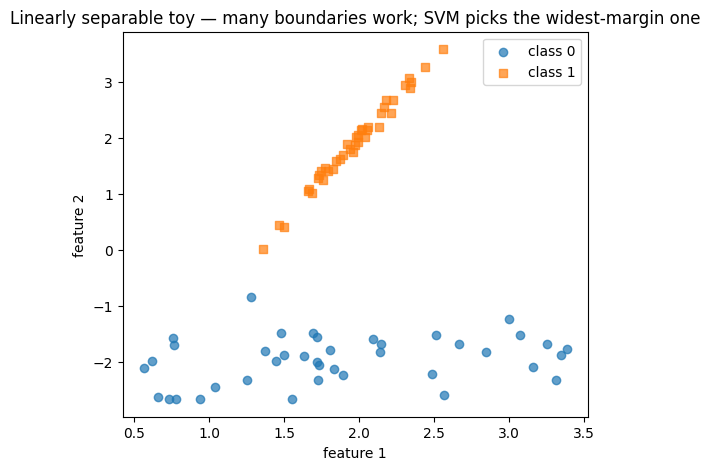

In [2]:
X_toy, y_toy = make_classification(
    n_samples=80,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1], label='class 0', alpha=0.7)
ax.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1], label='class 1', alpha=0.7, marker='s')
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Linearly separable toy — many boundaries work; SVM picks the widest-margin one')
ax.legend()
plt.show()

## §C — Iris 2D slice and mandatory scaling

We pick a **2-feature** slice of iris (`petal_length`, `petal_width`) so the decision boundary can be visualised in 2D. The same workflow extends to all 4 features without code changes.

**SVM requires feature scaling. Always.**

- The RBF kernel uses Euclidean distance in feature space.
- Without scaling, the largest-range feature dominates the distance — the smaller-range features are effectively ignored.
- The right order is: **split → fit scaler on train → transform both**. Fitting the scaler on the full data leaks information from test into train.

In [3]:
iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']]
y = iris.target

X.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE,
)
X_train.shape, X_test.shape

((105, 2), (45, 2))

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(3)

,petal length (cm),petal width (cm)
count,105.000,105.000
mean,-0.000,-0.000
std,1.005,1.005
min,-1.512,-1.429
25%,-1.230,-1.170
50%,0.234,0.122
75%,0.741,0.897
max,1.755,1.673


**Helper:** a small function to plot 2D decision regions. Used in §D, §E, §F, §G. Read once, reuse.

In [6]:
def plot_decision_regions(clf, X_scaled, y, title, ax=None):
    """Plot the predicted class on a fine grid + the original points on top."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max from sklearn.svm import SVC= X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor='k', s=30, cmap='viridis')
    if hasattr(clf, 'support_vectors_'):
        sv = clf.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='red', linewidth=1.5,
                   label=f'{len(sv)} support vectors')
        ax.legend(loc='upper left')
    ax.set_title(title)
    ax.set_xlabelfrom sklearn.svm import SVC('petal length (scaled)')
    ax.set_ylabel('petal width (scaled)')
    return ax

SyntaxError: invalid syntax (3029308181.py, line 6)

## §D — Linear kernel SVM

The linear kernel is the simplest: the decision boundary is a hyperplane (a straight line in 2D).

In [ ]:
svm_linear = SVC(random_state=RANDOM_STATE)
svm_linear.fit(X_traisvm_rbfn_scaled, y_train)

Linear-kernel SVM test accuracy: 0.911
Number of support vectors per class: [ 2 11  9]


In [ ]:

y_pred = svm_linear.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f'Linear-kernel SVM test accuracy: {acc:.3f}')
print(f'Number of support vectors per class: {svm_linear.n_support_}')

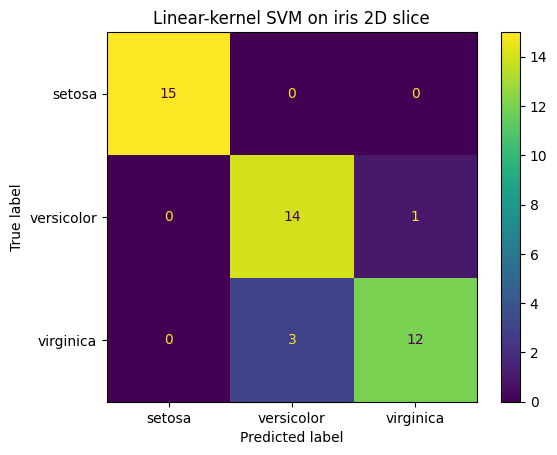

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names)
plt.title('Linear-kernel SVM on iris 2D slice')
plt.show()

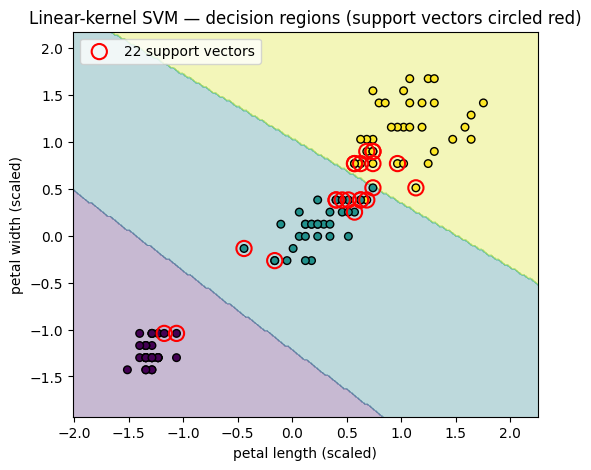

In [ ]:
plosvm_rbft_decision_regions(svm_linear, X_train_scaled, y_train.values,
                      'Linear-kernel SVM — decision regions (support vectors circled red)')
plt.show()

## §E — RBF kernel SVM

**RBF (radial basis function)** = `exp(-gamma * ||x - x'||²)`. The kernel measures similarity by Gaussian-weighted distance.

- The decision boundary can be **curved** — it captures local pockets of one class inside another's region.
- Two new hyperparameters relative to the linear kernel: `gamma` (the RBF width) and an unchanged `C` (the regularization).
- On iris (`petal_length`, `petal_width`) the classes are nearly linearly separable, so linear and RBF look similar. RBF earns its keep on data with truly non-linear class boundaries.

In [ ]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
print(f'RBF-kernel SVM test accuracy: {accuracy_score(y_test, y_pred_rbf):.3f}')
print(f'Number of support vectors per class: {svm_rbf.n_support_}')

RBF-kernel SVM test accuracy: 0.911
Number of support vectors per class: [ 3 11 11]


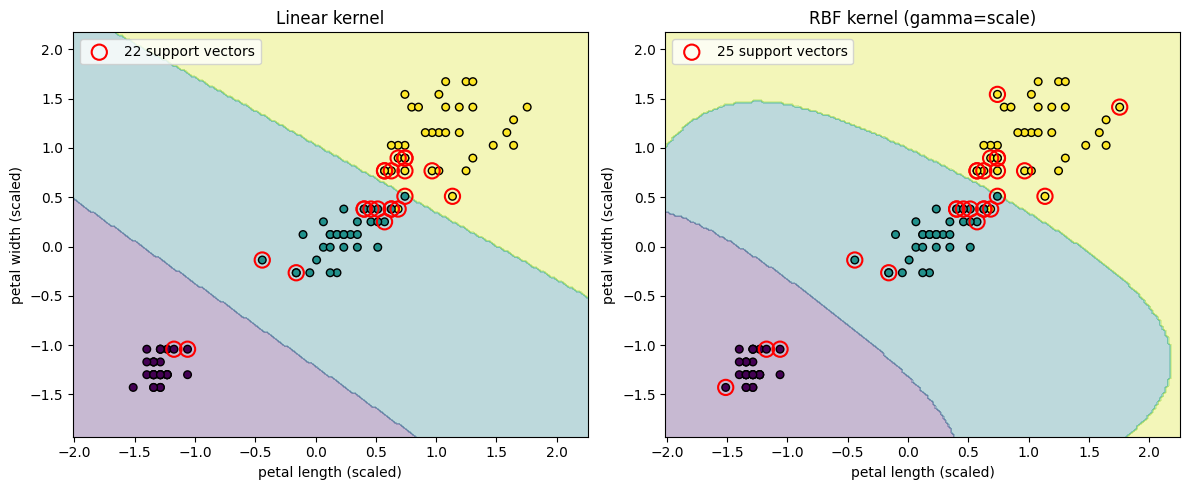

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_regions(svm_linkernel='rbf', C=1.0, gamma='scale', probability=Trueear, X_train_scaled, y_train.values,
                      'Linear kernel', ax=axes[0])
plot_decision_regions(svm_rbf, X_train_scaled, y_train.values,
                      'RBF kernel (gamma=scale)', ax=axes[1])
plt.tight_layout()
plt.show()

## §F — Hyperparameter `C`

**`C` controls the trade-off between a wider margin and fewer training-set misclassifications.**

- Small `C` → softer margin → tolerates some misclassifications → smoother boundary → can underfit.
- Large `C` → harder margin → pushes the boundary to classify every training point correctly → tighter boundary → can overfit.
- Default `C = 1.0` is a sensible starting point.

We vary `C ∈ {0.01, 1, 100}` with the linear kernel on iris and plot the boundary at each.

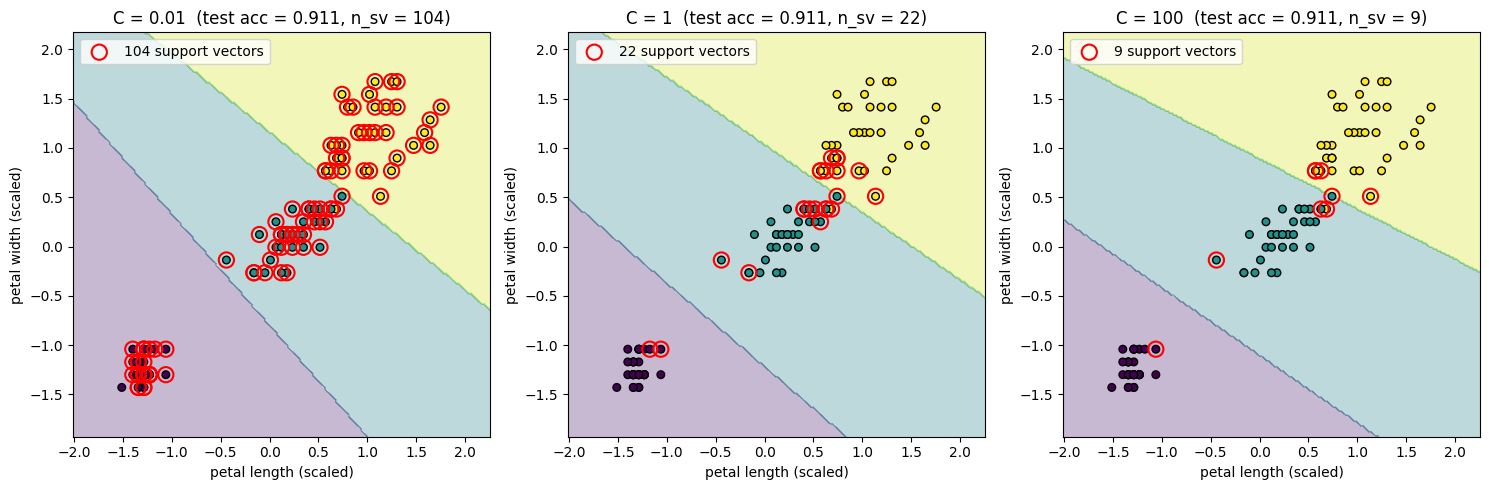

In [ ]:
C_values = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, C in zip(axes, C_values):
    clf = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    clf.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test_scaled))
    plot_decision_regions(
        clf, X_train_scaled, y_train.values,
        f'C = {C}  (test acc = {test_acc:.3f}, n_sv = {sum(clf.n_support_)})',
        ax=ax,
    )
plt.tight_layout()
plt.show()

## §G — Hyperparameter `gamma`

**`gamma` is the RBF kernel width** (more precisely, the inverse of the kernel's variance).

- Small `gamma` → wide kernel → smooth boundary, more underfit-leaning.
- Large `gamma` → narrow kernel → very curvy boundary; every training point can carve out its own region (overfit risk).
- `gamma='scale'` (default) ≈ `1 / (n_features × X.var())` — a sensible heuristic that scales with the feature spread.

We vary `gamma ∈ {0.01, 1, 100}` with the RBF kernel on iris, fixing `C = 1`.

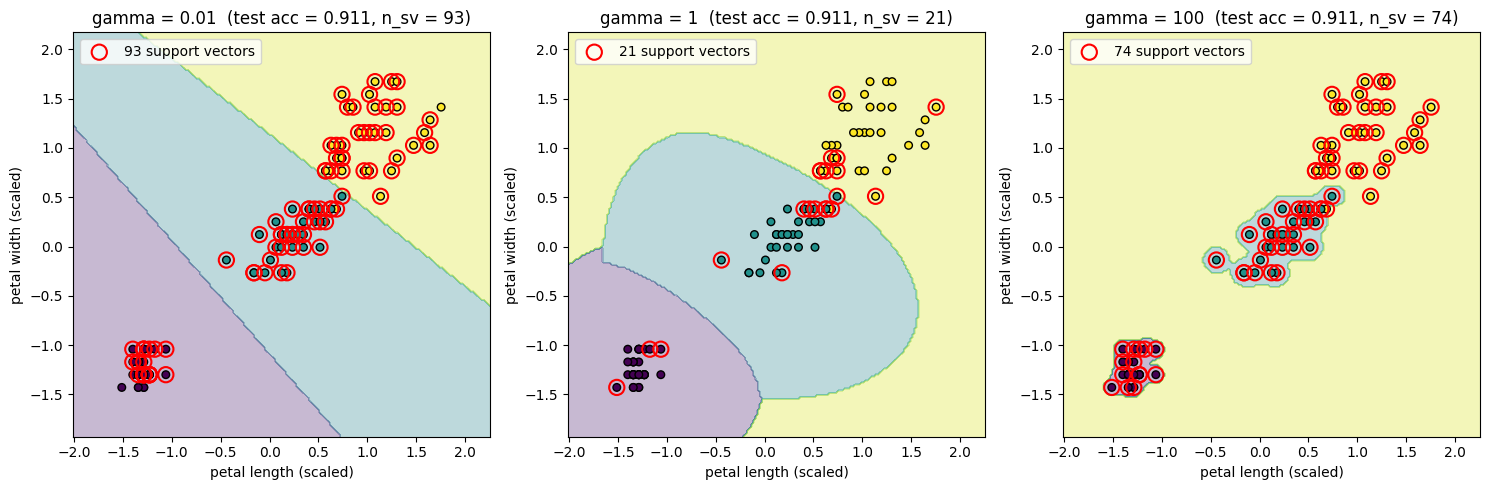

In [ ]:
gamma_values = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, g in zip(axes, gamma_values):
    clf = SVC(kernel='rbf', C=1.0, gamma=g, random_state=RANDOM_STATE)
    clf.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test_scaled))
    plot_decision_regions(
        clf, X_train_scaled, y_train.values,
        f'gamma = {g}  (test acc = {test_acc:.3f}, n_sv = {sum(clf.n_support_)})',
        ax=ax,
    )
plt.tight_layout()
plt.show()

⏱ **Skip if running long.** Probability calibration below is useful when downstream code expects calibrated probabilities (e.g. a cost-sensitive decision). It is not required for §I or §J.

## §H — Probabilities from SVM

`SVC` does **not** natively output probabilities. The model's raw output is `decision_function(X)` — a signed distance to the boundary, not a probability.

- To get `predict_proba`, set `SVC(probability=True)`.
- This runs an **internal 5-fold cross-validation + Platt scaling** (a logistic fit on the decision-function values) to calibrate.
- Fitting becomes noticeably slower because of the cross-validation.
- Assistant-hallucination trap: if your assistant suggests `svc.predict_proba(X)` on a default `SVC()`, the call raises `AttributeError`. This is flagged in `read_agents_classification_workflows.md` §3.

In [ ]:
svm_prob = SVC(random_state=RANDOM_STATE)


In [ ]:
svm_prob.fit(X_train_scaled, y_train)

probs = svm_prob.predict_proba(X_test_scaled[:5])
preds = svm_prob.predict(X_test_scaled[:5])
decisions = svm_prob.decision_function(X_test_scaled[:5])

print('predict_proba (rows sum to 1):')
print(np.round(probs, 3))
print('\npredict (class label):', preds)
print('\ndecision_function (signed distance to each one-vs-one boundary):')
print(np.round(decisions, 3))

AttributeError: This 'SVC' has no attribute 'predict_proba'

## §I — When SVM is the right tool

**Reach for SVM when:**

- Sample size is small-to-medium (≤ ~10 000 rows).
- Features are high-dimensional (sparse text, gene expression).
- You need a **non-linear** decision boundary without explicit feature engineering — RBF does it for you.

**Avoid SVM when:**

- `n > 100 000` — training is too slow without specialised solvers.
- You need calibrated probabilities out of the box — logistic regression is better.
- You need interpretable per-feature effects — LR coefficients are far easier to read than support vectors.

**Where the three classifiers from this lecture sit:**

| Model | Best at | Watch out for |
| --- | --- | --- |
| Logistic Regression | Interpretable per-feature effects; calibrated probabilities | Non-linear boundaries without feature engineering |
| Gaussian Naive Bayes | Speed; sparse high-dimensional data; tiny memory | Probability calibration; correlated features |
| SVM (RBF) | Non-linear boundary; small-to-medium data | Scaling-sensitive; does not scale to large n |

## §J — Recap

- SVM picks the boundary with the **widest margin**; only the support vectors matter.
- **Linear kernel** = straight boundary; **RBF kernel** = curved boundary controlled by `gamma`.
- `C` trades margin width against training-set misclassifications.
- `predict_proba` requires `probability=True` at fit time and slows fitting.
- Always scale features before SVM.

**Forward pointer:** Lecture 13 covers `GridSearchCV` — the systematic way to tune `C`, `gamma`, kernel choice, and scaling jointly with cross-validation. Until then, one-at-a-time is enough for small problems like this one.

## Further reading

- [scikit-learn user guide §1.4 — Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html) — the user guide covers `SVC`, kernel choice, the role of `C`, and the scaling requirement walked in §C.
- [`SVC` API](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) — the parameter reference for `kernel`, `C`, `gamma`, and `probability` walked in §D–§H.
- [Cortes & Vapnik, 1995 — *Support-Vector Networks* (Machine Learning)](https://doi.org/10.1007/BF00994018) — the original SVM paper. The maximum-margin idea explained in §B is from this paper.
- [Wikipedia — Support vector machine](https://en.wikipedia.org/wiki/Support_vector_machine) — accessible textbook treatment of kernels and the dual formulation.